In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import defaultdict

compterles images par classes 

In [7]:
def compter_classes(base_path):
    resultats = {}
    for split in ['train', 'test']:
        split_path = os.path.join(base_path, split)
        resultats[split] = {}
        for classe in os.listdir(split_path):
            classe_path = os.path.join(split_path, classe)
            if os.path.isdir(classe_path):
                nb = len(os.listdir(classe_path))
                resultats[split][classe] = nb
    return resultats

# Chemins corrigés
oct_stats  = compter_classes("../data/OCT")
xray_stats = compter_classes("../data/chest_xray")

print("=== OCT ===")
for split, classes in oct_stats.items():
    print(f"\n{split.upper()} :")
    for classe, nb in classes.items():
        print(f"  {classe} : {nb} images")

print("\n=== CHEST X-RAY ===")
for split, classes in xray_stats.items():
    print(f"\n{split.upper()} :")
    for classe, nb in classes.items():
        print(f"  {classe} : {nb} images")

=== OCT ===

TRAIN :
  CNV : 37205 images
  DME : 11348 images
  DRUSEN : 8616 images
  NORMAL : 26315 images

TEST :
  CNV : 250 images
  DME : 250 images
  DRUSEN : 250 images
  NORMAL : 250 images

=== CHEST X-RAY ===

TRAIN :
  NORMAL : 1349 images
  PNEUMONIA : 3884 images

TEST :
  NORMAL : 234 images
  PNEUMONIA : 390 images


Visualiser la distribution (graphiques)

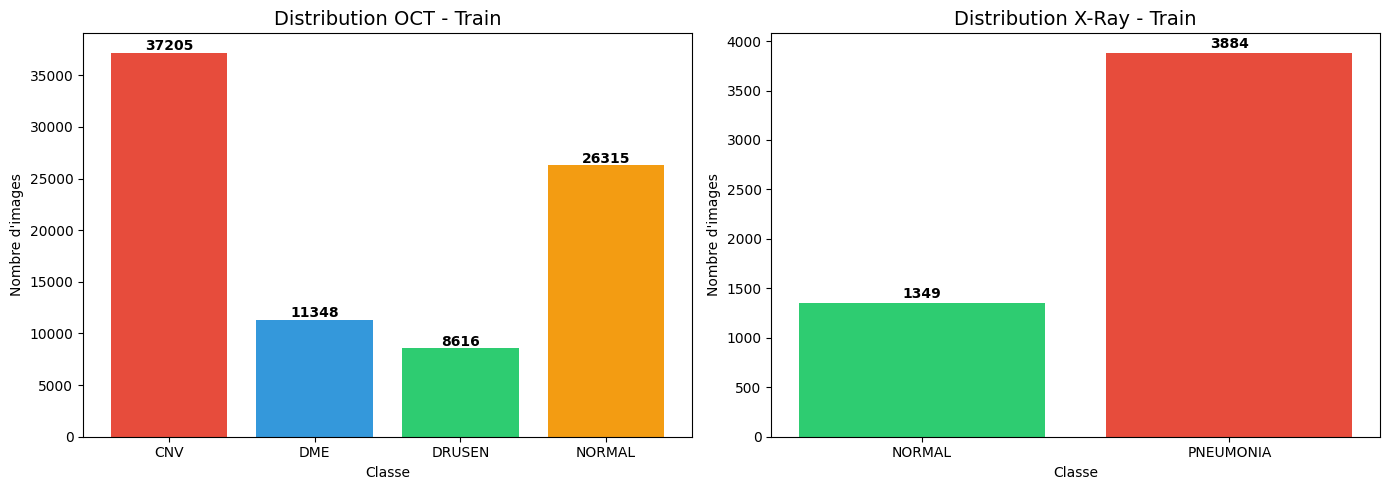

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── OCT ──────────────────────────────────────
oct_classes = list(oct_stats['train'].keys())
oct_counts  = list(oct_stats['train'].values())

axes[0].bar(oct_classes, oct_counts,
            color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
axes[0].set_title("Distribution OCT - Train", fontsize=14)
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Nombre d'images")
for i, v in enumerate(oct_counts):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# ── X-RAY ────────────────────────────────────
xray_classes = list(xray_stats['train'].keys())
xray_counts  = list(xray_stats['train'].values())

axes[1].bar(xray_classes, xray_counts,
            color=['#2ecc71','#e74c3c'])
axes[1].set_title("Distribution X-Ray - Train", fontsize=14)
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("Nombre d'images")
for i, v in enumerate(xray_counts):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("../results/distribution_classes.png")
plt.show()

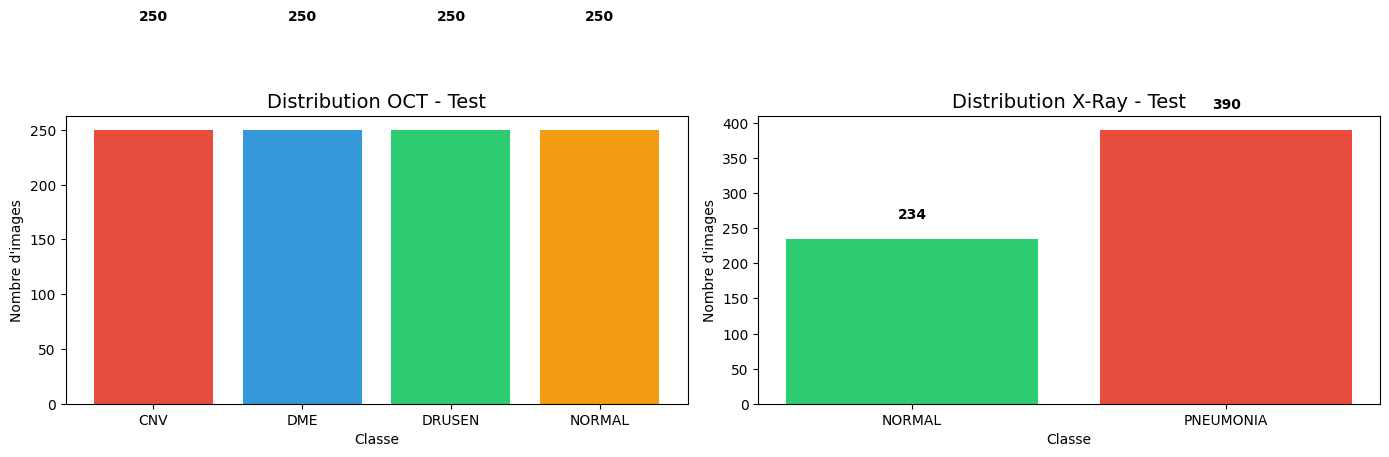

In [10]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── OCT ──────────────────────────────────────
oct_classes = list(oct_stats['test'].keys())
oct_counts  = list(oct_stats['test'].values())

axes[0].bar(oct_classes, oct_counts,
            color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
axes[0].set_title("Distribution OCT - Test", fontsize=14)
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Nombre d'images")
for i, v in enumerate(oct_counts):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# ── X-RAY ────────────────────────────────────
xray_classes = list(xray_stats['test'].keys())
xray_counts  = list(xray_stats['test'].values())

axes[1].bar(xray_classes, xray_counts,
            color=['#2ecc71','#e74c3c'])
axes[1].set_title("Distribution X-Ray - Test", fontsize=14)
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("Nombre d'images")
for i, v in enumerate(xray_counts):
    axes[1].text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("../results/distribution_classes_test.png")
plt.show()

Visualiser des exemples d'images

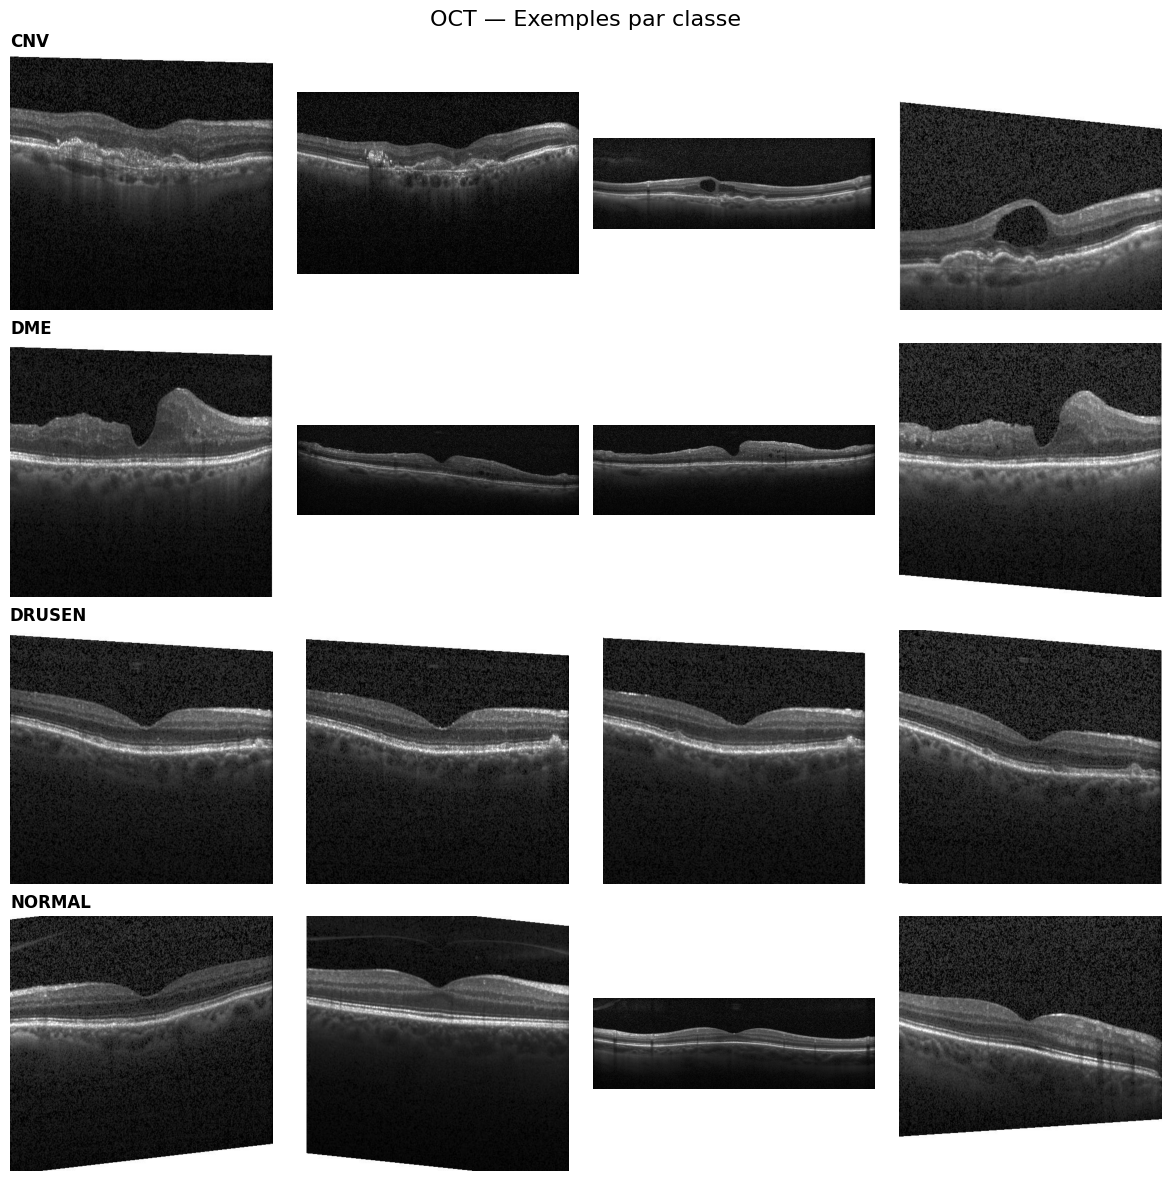

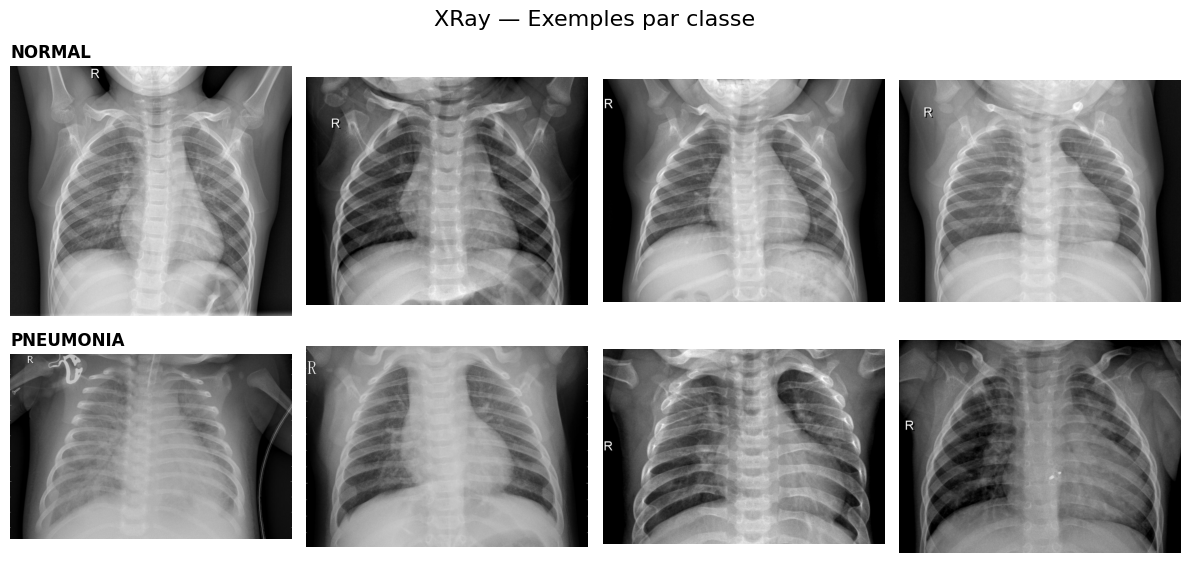

In [14]:
from PIL import Image 
def afficher_exemples(base_path, dataset_name, split='train', n=4):
    classes = os.listdir(os.path.join(base_path, split))
    fig, axes = plt.subplots(len(classes), n,
                             figsize=(n * 3, len(classes) * 3))
    fig.suptitle(f"{dataset_name} — Exemples par classe", fontsize=16)

    for i, classe in enumerate(classes):
        classe_path = os.path.join(base_path, split, classe)
        images      = os.listdir(classe_path)[:n]

        for j, img_file in enumerate(images):
            img = Image.open(os.path.join(classe_path, img_file))
            axes[i][j].imshow(img, cmap='gray')
            axes[i][j].axis('off')
            if j == 0:
                axes[i][j].set_title(classe, fontsize=12,
                                     fontweight='bold', loc='left')

    plt.tight_layout()
    plt.savefig(f"../results/exemples_{dataset_name}.png")
    plt.show()

afficher_exemples("../data/OCT",         "OCT")
afficher_exemples("../data/chest_xray",  "XRay")

Analyser les tailles des images

In [15]:
import numpy as np

def analyser_tailles(base_path, split='train', max_images=100):
    largeurs, hauteurs = [], []

    for classe in os.listdir(os.path.join(base_path, split)):
        classe_path = os.path.join(base_path, split, classe)
        images      = os.listdir(classe_path)[:max_images]

        for img_file in images:
            try:
                img = Image.open(os.path.join(classe_path, img_file))
                w, h = img.size
                largeurs.append(w)
                hauteurs.append(h)
            except:
                pass

    print(f"Largeur  — min: {min(largeurs)}  max: {max(largeurs)}  moyenne: {np.mean(largeurs):.0f}")
    print(f"Hauteur  — min: {min(hauteurs)}  max: {max(hauteurs)}  moyenne: {np.mean(hauteurs):.0f}")

print("=== OCT ===")
analyser_tailles("../data/OCT")

print("\n=== X-RAY ===")
analyser_tailles("../data/chest_xray")

=== OCT ===
Largeur  — min: 512  max: 1536  moyenne: 678
Hauteur  — min: 496  max: 512  moyenne: 500

=== X-RAY ===
Largeur  — min: 502  max: 2396  moyenne: 1457
Hauteur  — min: 307  max: 2025  moyenne: 1105


Détecter le déséquilibre

In [16]:
def calculer_desequilibre(stats, split='train'):
    counts = list(stats[split].values())
    total  = sum(counts)
    maxi   = max(counts)
    mini   = min(counts)
    ratio  = maxi / mini

    print(f"Total images : {total}")
    print(f"Ratio max/min : {ratio:.1f}x")

    if ratio > 3:
        print("⚠️  Déséquilibre important → utiliser class weights !")
    else:
        print("✅  Déséquilibre acceptable")

print("=== OCT ===")
print(oct_stats)
calculer_desequilibre(oct_stats)

print("\n=== X-RAY ===")
print(xray_stats)
calculer_desequilibre(xray_stats)

=== OCT ===
{'train': {'CNV': 37205, 'DME': 11348, 'DRUSEN': 8616, 'NORMAL': 26315}, 'test': {'CNV': 250, 'DME': 250, 'DRUSEN': 250, 'NORMAL': 250}}
Total images : 83484
Ratio max/min : 4.3x
⚠️  Déséquilibre important → utiliser class weights !

=== X-RAY ===
{'train': {'NORMAL': 1349, 'PNEUMONIA': 3884}, 'test': {'NORMAL': 234, 'PNEUMONIA': 390}}
Total images : 5233
Ratio max/min : 2.9x
✅  Déséquilibre acceptable


Résumé 

In [17]:
print("=" * 45)
print("        RÉSUMÉ EXPLORATION")
print("=" * 45)
print(f"OCT   — Total train : {sum(oct_stats['train'].values())}")
print(f"OCT   — Total test  : {sum(oct_stats['test'].values())}")
print(f"XRay  — Total train : {sum(xray_stats['train'].values())}")
print(f"XRay  — Total test  : {sum(xray_stats['test'].values())}")
print(f"Nb classes OCT      : {len(oct_stats['train'])}")
print(f"Nb classes XRay     : {len(xray_stats['train'])}")
print("=" * 45)

        RÉSUMÉ EXPLORATION
OCT   — Total train : 83484
OCT   — Total test  : 1000
XRay  — Total train : 5233
XRay  — Total test  : 624
Nb classes OCT      : 4
Nb classes XRay     : 2
